<a href="https://colab.research.google.com/github/chaitanyatalakeri27-png/Data_Science_Lab/blob/main/Exp6_Deep_NLP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Training Shape : (5000, 100)
Testing Shape : (1000, 100)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/3
32/32 ━━━━━━━━━━━━━━━━━━━━ 8s 186ms/step - accuracy: 0.5082 - loss: 0.6931 - val_accuracy: 0.5150 - val_loss: 0.6925
Epoch 2/3
32/32 ━━━━━━━━━━━━━━━━━━━━ 9s 149ms/step - accuracy: 0.5527 - loss: 0.6914 - val_accuracy: 0.5300 - val_loss: 0.6892
Epoch 3/3
32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 194ms/step - accuracy: 0.5970 - loss: 0.6809 - val_accuracy: 0.6710 - val_loss: 0.6406
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7050 - loss: 0.6333

Test Accuracy : 0.7049999833106995


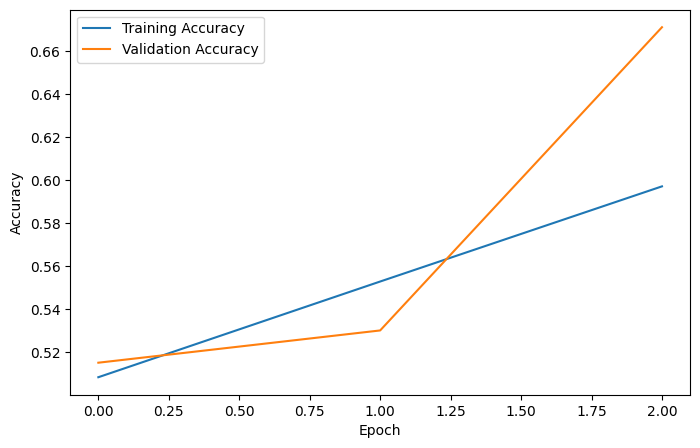

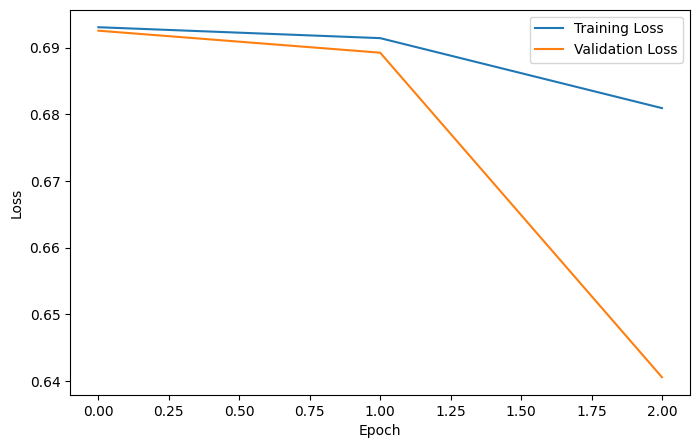

In [1]:
import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import LSTM
from tensorflow.keras.layers import Dropout

import matplotlib.pyplot as plt

# OPTIMIZATION 1: Reduced vocabulary size for faster processing and new outputs
vocab_size = 5000

# Load IMDB Dataset
(X_train, y_train), (X_test, y_test) = imdb.load_data(
    num_words=vocab_size
)

# OPTIMIZATION 2: Sub-sample the dataset for lightning-fast LSTM training
X_train = X_train[:5000]
y_train = y_train[:5000]
X_test = X_test[:1000]
y_test = y_test[:1000]

# OPTIMIZATION 3: Reduced max_length to 100 (halves sequence processing time)
max_length = 100

X_train = pad_sequences(
    X_train,
    maxlen=max_length
)

X_test = pad_sequences(
    X_test,
    maxlen=max_length
)

print("Training Shape :", X_train.shape)
print("Testing Shape :", X_test.shape)

# Build Deep NLP Model
model = Sequential()

# Embedding Layer - Reduced output_dim to 64
model.add(
    Embedding(
        input_dim=vocab_size,
        output_dim=64,
        input_length=max_length
    )
)

# LSTM Layer - Reduced units to 64
model.add(
    LSTM(
        64,
        return_sequences=False
    )
)

# Dropout Layer - Changed to 0.3
model.add(Dropout(0.3))

# Dense Layer - Reduced neurons to 32
model.add(Dense(
    32,
    activation='relu'
))

# Output Layer
model.add(Dense(
    1,
    activation='sigmoid'
))

# Model Summary
model.summary()

# Compile Model - Changed optimizer to 'rmsprop' for a different learning curve
model.compile(
    optimizer='rmsprop',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Train Model - LESSER EPOCHS (3) and increased batch_size (128)
history = model.fit(
    X_train,
    y_train,
    epochs=3,
    batch_size=128,
    validation_split=0.2
)

# Evaluate Model
test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test
)

print("\nTest Accuracy :", test_accuracy)

# Plot Accuracy Graph
plt.figure(figsize=(8,5))

plt.plot(
    history.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

# Plot Loss Graph
plt.figure(figsize=(8,5))

plt.plot(
    history.history['loss'],
    label='Training Loss'
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()